# **Análisis de Coexistencia LV para simulaciones HOOMD-blue**
**Comparación con datos de referencia NIST (Mie potential)**

* **Autor:** Fabio Noriega Hernández
* **Fecha:** Abril 2026

In [53]:
import os
import glob
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

# Asegúrate de que tu archivo funciones.py esté en el mismo directorio que este notebook
from funciones import calcular_perfil_densidad_gsd 

# Configuración de gráficos en línea para Jupyter
%matplotlib inline

# -- CONFIGURACIÓN --
num_prueba = 4
num_bines = 100
start_frame = 10  # Ajustar según cuándo empiece el equilibrio en tus GSD

# -- DATOS NIST --
nist_rho_l = [8.643e-01, 8.203e-01, 7.728e-01, 7.203e-01, 6.592e-01, 5.807e-01, 4.367e-01]
nist_rho_v = [8.450e-04, 3.508e-03, 1.004e-02, 2.304e-02, 4.664e-02, 9.047e-02, 2.047e-01]

# -- DATOS SIMULACIONES CÓDIGO DOC. LUIS -- 
# c_rho_l = [0.8732, 0.8295, 0.7842, 0.7317, 0.6732, 0.5858]
# c_rho_v = [0.0008, 0.0026, 0.008, 0.0195, 0.0366, 0.0710]

# Temperaturas (asegúrate de que coincidan con las carpetas generadas)
temperaturas_originales = [0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20]
ruta_comun_base = f'/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/HOOMD/P{num_prueba}_HOOMD_Mie'
ruta_graficos = os.path.join(ruta_comun_base, 'Graficos_Analisis')

if not os.path.exists(ruta_graficos):
    os.makedirs(ruta_graficos, exist_ok=True)

In [54]:
densidades_liquido = []
densidades_vapor = []
std_liquido = []
std_vapor = []
temps_ejecutadas = []

# Parámetros para promediar las fases en el perfil
centro = num_bines // 2
margen = 5
n = 0

for T in temperaturas_originales:
    # Caso especial para T = 1.20 debido a diferente ruta/estructura
    if T == 1.20:
        ruta_comun = f'/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/HOOMD/P6_HOOMD_Mie'
        nombre_carpeta = 'N_71_45_25'
    else:
        ruta_comun = ruta_comun_base
        nombre_carpeta = f"T={T:.2f}"
    
    ruta_busqueda = os.path.join(ruta_comun, nombre_carpeta, f"trajectory_T{T:.2f}.gsd")
    archivos = glob.glob(ruta_busqueda)

    if not archivos:
        print(f"⚠️ No se encontró archivo para T={T:.2f} en: {ruta_busqueda}")
        continue

    archivo_gsd = archivos[0]
    print(f'Procesando GSD: {archivo_gsd}')


    try:
        x, rho_prom, rho_std = calcular_perfil_densidad_gsd(
            gsd_file=archivo_gsd, 
            start_frame=start_frame, 
            num_bines=num_bines)
        
        if T == 1.20:
            # Si la gráfica muestra el vapor en el centro:
            bines_vapor = rho_prom[centro - margen : centro + margen]
            rho_v = bines_vapor.mean()
            std_v = rho_std[centro - margen : centro + margen].mean()

            bines_liquido = np.concatenate([rho_prom[:10], rho_prom[-10:]])
            rho_l = bines_liquido.mean()
            std_l = rho_std[:10].mean()

        else:
            # Cálculo de densidades de fase (Líquido al centro, Vapor a los extremos)
            bines_liquido = rho_prom[centro - margen : centro + margen]
            rho_l = bines_liquido.mean()
            std_l = rho_std[centro - margen : centro + margen].mean()

            bines_vapor = np.concatenate([rho_prom[:10], rho_prom[-10:]])
            rho_v = bines_vapor.mean()
            std_v = rho_std[:10].mean()

        densidades_liquido.append(rho_l)
        std_liquido.append(std_l)
        densidades_vapor.append(rho_v)
        std_vapor.append(std_v)
        temps_ejecutadas.append(T)

        print(f"T={T:.2f} | rho_L: {rho_l:.4f} | rho_V: {rho_v:.4f}")
        
        # Evitar desbordamiento de índice si hay más temperaturas ejecutadas que datos NIST
        if n < len(nist_rho_l):
            print("Error absoluto respecto a NIST:")
            print(f"  Líquido: {nist_rho_l[n]:.4f} - {rho_l:.4f} = {abs(nist_rho_l[n] - rho_l):.4f}")
            print(f"  Vapor:   {nist_rho_v[n]:.4f} - {rho_v:.4f} = {abs(nist_rho_v[n] - rho_v):.4f}")
        else:
            print("  (Sin datos NIST de referencia para esta temperatura)")
            
        print("-" * 60)
        n += 1

    except Exception as e:
        print(f"❌ Error procesando T={T}: {e}")

Procesando GSD: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/HOOMD/P4_HOOMD_Mie/T=0.60/trajectory_T0.60.gsd
Dimensiones de la caja: Lx=48.9200, Ly=24.4600, Lz=24.4600
Procesando 21 frames de 31 totales...
Frame procesado: 30/31
✅ Cálculo de perfil completado.
T=0.60 | rho_L: 0.8717 | rho_V: 0.0007
Error absoluto respecto a NIST:
  Líquido: 0.8643 - 0.8717 = 0.0074
  Vapor:   0.0008 - 0.0007 = 0.0002
------------------------------------------------------------
Procesando GSD: /run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/HOOMD/P4_HOOMD_Mie/T=0.70/trajectory_T0.70.gsd
Dimensiones de la caja: Lx=48.9200, Ly=24.4600, Lz=24.4600
Procesando 21 frames de 31 totales...
Frame procesado: 30/31
✅ Cálculo de perfil completado.
T=0.70 | rho_L: 0.8305 | rho_V: 0.0029
Error absoluto respecto a NIST:
  Líquido: 0.8203 - 0.8305 = 0.0102
  Vapor:   0.0035 - 0.0029 = 0.0006
------------------------------------------------------------
Procesando GSD: /run/media/fabio-nor

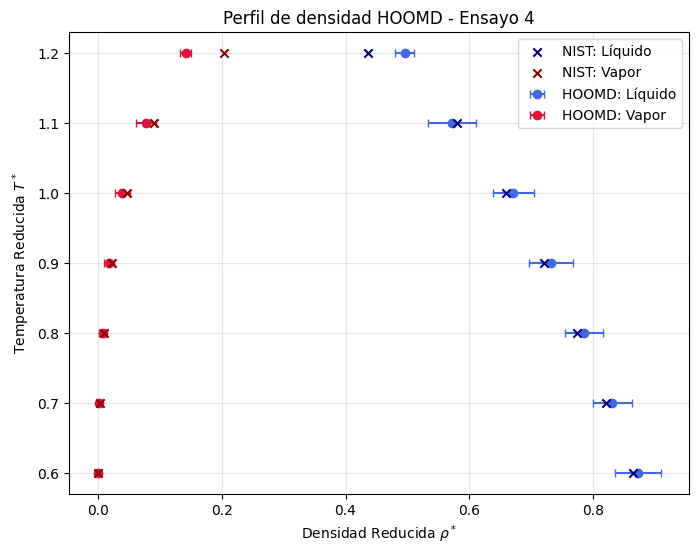

In [55]:
plt.figure(figsize=(8, 6))

# Datos Simulación
plt.errorbar(densidades_liquido, temps_ejecutadas, xerr=std_liquido, 
             fmt='o', color='royalblue', label='HOOMD: Líquido', capsize=3)
plt.errorbar(densidades_vapor, temps_ejecutadas, xerr=std_vapor, 
             fmt='o', color='crimson', label='HOOMD: Vapor', capsize=3)

# Datos NIST y otras SIM (Ajustamos el slice para que coincida con lo procesado)
n_puntos = len(temps_ejecutadas)

plt.scatter(nist_rho_l[:n_puntos], temperaturas_originales[:n_puntos], 
            marker='x', color='navy', label='NIST: Líquido', zorder=5)
plt.scatter(nist_rho_v[:n_puntos], temperaturas_originales[:n_puntos], 
            marker='x', color='darkred', label='NIST: Vapor', zorder=5)

# plt.scatter(c_rho_l[:n_puntos], temperaturas_originales[:n_puntos],
#             marker='s', color='green', label='SIM: Líquido', zorder=5)
# plt.scatter(c_rho_v[:n_puntos], temperaturas_originales[:n_puntos],
#             marker='s', color='orange', label='SIM: Vapor', zorder=5)

plt.title(f'Perfil de densidad HOOMD - Ensayo {num_prueba}')
plt.xlabel(r'Densidad Reducida $\rho^*$')
plt.ylabel(r'Temperatura Reducida $T^*$')
plt.legend()
plt.grid(alpha=0.3)

# Guardar y mostrar
plt.savefig(os.path.join(ruta_graficos, 'campana_coexistencia.png'), dpi=300)
plt.show()

In [56]:
def calcular_error(sim, ref):
    sim, ref = np.array(sim), np.array(ref[:len(sim)])
    mae = np.mean(np.abs(sim - ref))
    mre = np.mean(np.abs((sim - ref) / ref)) * 100
    return mae, mre

# Calcular errores basándose solo en los puntos donde hay datos NIST disponibles
puntos_comunes = min(len(densidades_liquido), len(nist_rho_l))

mae_l, mre_l = calcular_error(densidades_liquido[:puntos_comunes], nist_rho_l[:puntos_comunes])
mae_v, mre_v = calcular_error(densidades_vapor[:puntos_comunes], nist_rho_v[:puntos_comunes])

print(f"{' RESULTADOS VS NIST ':^40}")
print("-" * 40)
print(f"Líquido - MAE: {mae_l:.4f} | MRE: {mre_l:.2f}%")
print(f"Vapor   - MAE: {mae_v:.4f} | MRE: {mre_v:.2f}%")

           RESULTADOS VS NIST           
----------------------------------------
Líquido - MAE: 0.0172 | MRE: 3.14%
Vapor   - MAE: 0.0128 | MRE: 19.39%
